In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

#Guardar datos en fichero csv por si tengo que visualizarlos
#file_path = '/content/drive/MyDrive/dataScience/analisis_datos/semana_04/diamonds.csv'
#diamonds.to_csv(file_path, index=False)
#file_path
#Guardar datos en fichero csv por si tengo que visualizarlos


diamonds = sns.load_dataset('diamonds')

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


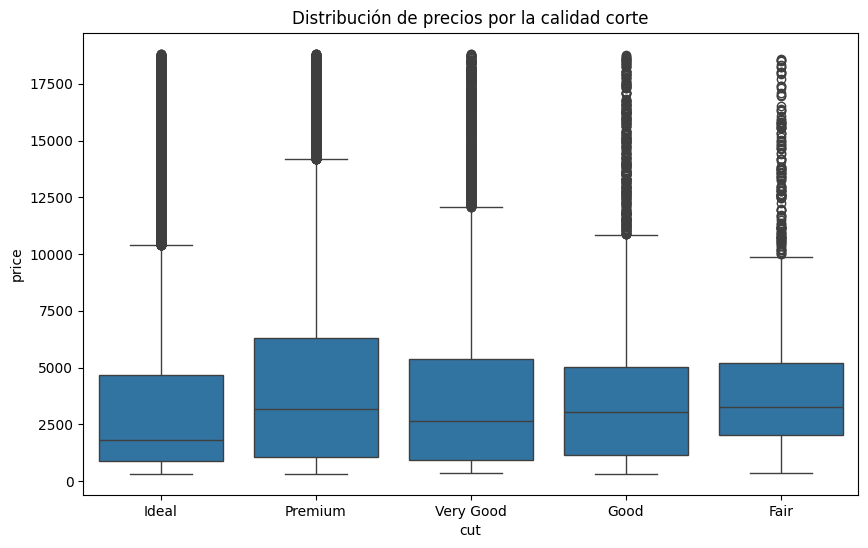

In [15]:
#Míralo gráfica y numéricamente.
import matplotlib.pyplot as plt

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='cut', y='price', data=diamonds)
plt.title('Distribución de precios por la calidad corte')
plt.show()

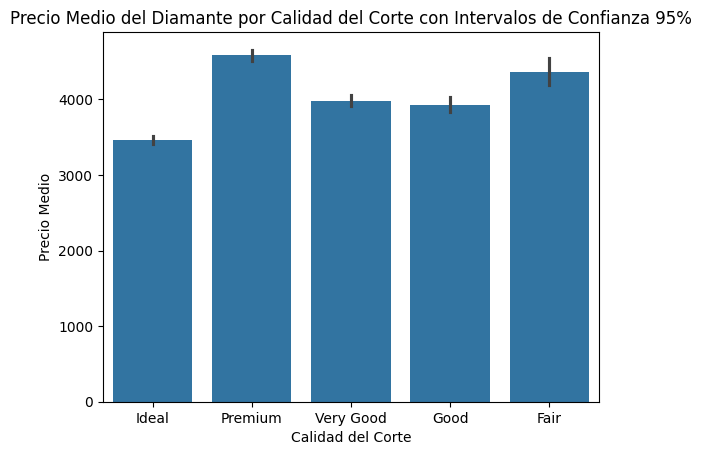

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico con intervalos de confianza 95%`
sns.barplot(x='cut', y='price', data=diamonds, errorbar=('ci', 95))
plt.title('Precio Medio del Diamante por Calidad del Corte con Intervalos de Confianza 95%')
plt.ylabel('Precio Medio')
plt.xlabel('Calidad del Corte')
plt.show()


In [19]:

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Realizar ANOVA usando OLS (Ordinary Least Squares)
modelo = ols('price ~ C(cut)', data=diamonds).fit()
anova = sm.stats.anova_lm(modelo)

# Calcular eta squared (η²) utilizando iloc para evitar la advertencia
eta_squared = anova['sum_sq'].iloc[0] / anova['sum_sq'].sum()


#print(anova['sum_sq'].sum())
print(f"resultado de η entre 'cut' y 'price': {eta_squared}")

resultado de η entre 'cut' y 'price': 0.012862074422402031


In [20]:
#Descripción estadística del precio agrupado por la calidad del corte
price_cut = diamonds.groupby('cut', observed=False)['price'].describe()
price_cut

,count,mean,std,min,25%,50%,75%,max
cut,,,,,,,,
Ideal,21551.0,3457.541970,3808.401172,326.0,878.00,1810.0,4678.50,18806.0
Premium,13791.0,4584.257704,4349.204961,326.0,1046.00,3185.0,6296.00,18823.0
Very Good,12082.0,3981.759891,3935.862161,336.0,912.00,2648.0,5372.75,18818.0
Good,4906.0,3928.864452,3681.589584,327.0,1145.00,3050.5,5028.00,18788.0
Fair,1610.0,4358.757764,3560.386612,337.0,2050.25,3282.0,5205.50,18574.0


**3.** Interpreta brevemente los resultados de la tarea 2 (máximo 600 palabras).  
El análisis sugiere que existe una relación significativa entre la calidad del corte y el precio del diamante. Los diamantes con cortes de mayor calidad tienden a tener precios más altos. El valor de **eta_squared = 0.0129** indica que la calidad del corte tiene un impacto moderado en el precio, lo que quiere decir que otras variables tmbien influyen en el precio.

**4.** Mira si existen relaciones entre el precio de venta (price) y el peso del diamante
(carat). Míralo gráfica y numéricamente

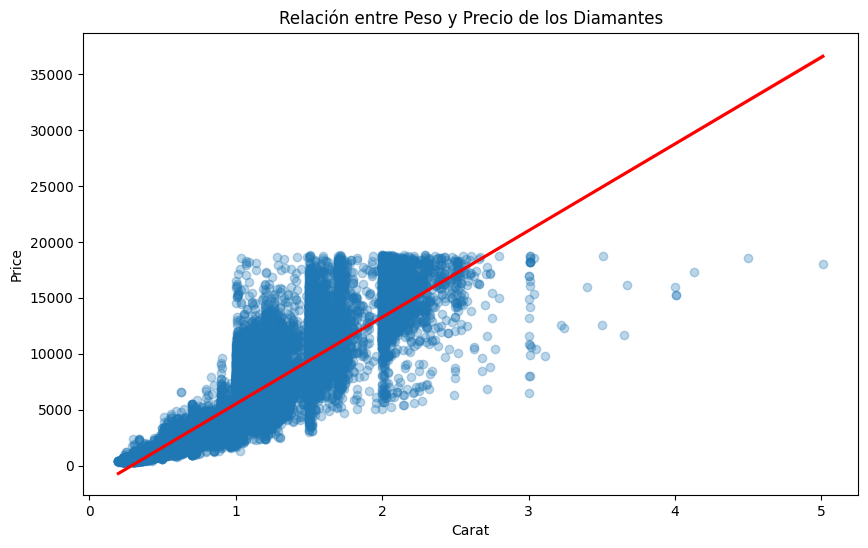

In [23]:
# Gráfico dispersión con línea de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x='carat', y='price', data=diamonds, scatter_kws={'alpha':0.3}, line_kws={"color": "red"})
plt.title('Relación entre Peso y Precio de los Diamantes')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()




In [10]:

# Calcular el coeficiente de correlación de Pearson entre 'carat' y 'price'
correlation = diamonds['carat'].corr(diamonds['price'])
print(f"Coeficiente de correlación de Pearson entre 'carat' y 'price': {correlation}")


Coeficiente de correlación de Pearson entre 'carat' y 'price': 0.9215913011934771


El gráfico muestra claramente una relación positiva entre el peso del diamante 'carat' y su precio. A medida que el peso aumenta, el precio también lo hace, lo que es consistente con el **coeficiente de correlación de Pearson= 0.9216**

**5.** Mira si existen relaciones entre el precio de venta (price) y el peso del diamante
(carat), según la calidad del corte (cut). Míralo gráfica y numéricamente

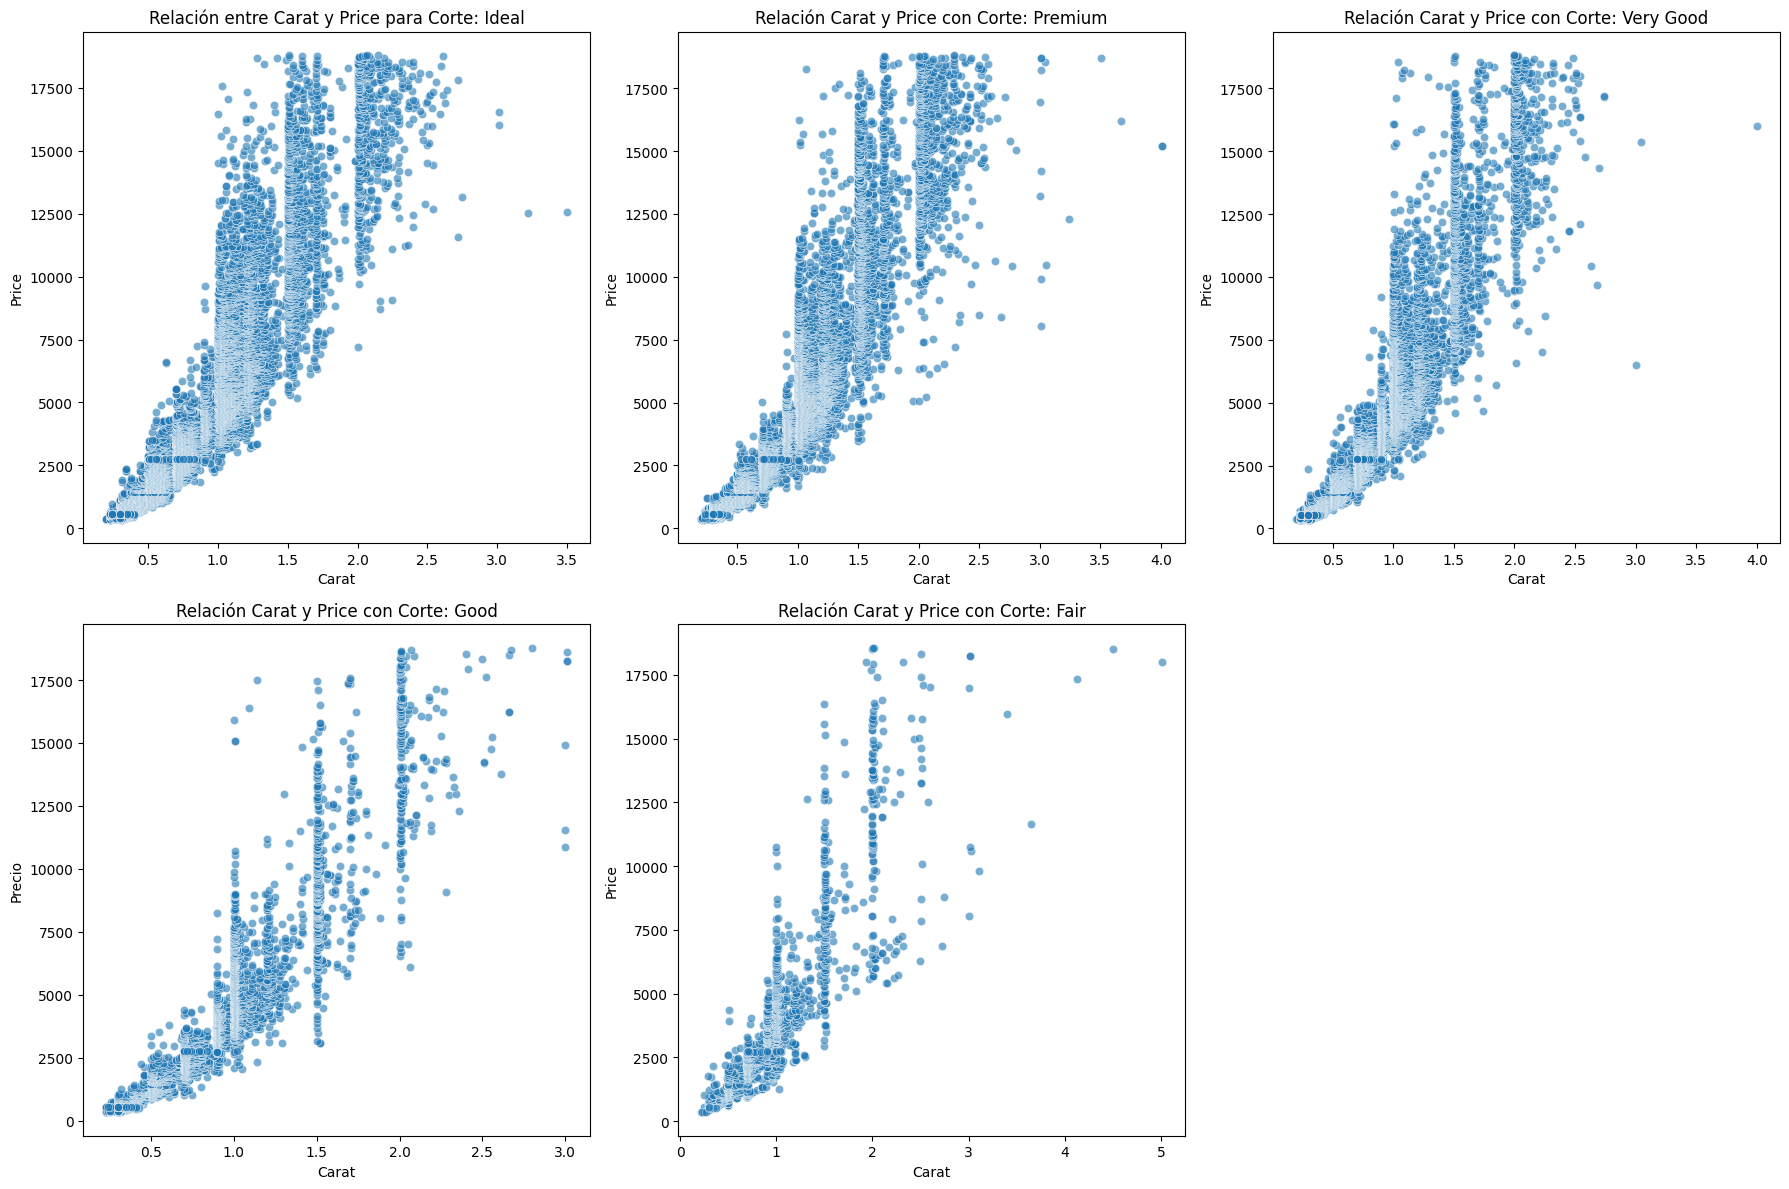

In [13]:
# Gráficos de dispersión
plt.figure(figsize=(18, 12))

# Ideal'
plt.subplot(2, 3, 1)
sns.scatterplot(x='carat', y='price', data=diamonds[diamonds['cut'] == 'Ideal'], alpha=0.6)
plt.title('Relación entre Carat y Price para Corte: Ideal')
plt.xlabel('Carat')
plt.ylabel('Price')

# 'Premium'
plt.subplot(2, 3, 2)
sns.scatterplot(x='carat', y='price', data=diamonds[diamonds['cut'] == 'Premium'], alpha=0.6)
plt.title('Relación Carat y Price con Corte: Premium')
plt.xlabel('Carat')
plt.ylabel('Price')

# 'Very Good'
plt.subplot(2, 3, 3)
sns.scatterplot(x='carat', y='price', data=diamonds[diamonds['cut'] == 'Very Good'], alpha=0.6)
plt.title('Relación Carat y Price con Corte: Very Good')
plt.xlabel('Carat')
plt.ylabel('Price')

# 'Good'
plt.subplot(2, 3, 4)
sns.scatterplot(x='carat', y='price', data=diamonds[diamonds['cut'] == 'Good'], alpha=0.6)
plt.title('Relación Carat y Price con Corte: Good')
plt.xlabel('Carat')
plt.ylabel('Precio')

# 'Fair'
plt.subplot(2, 3, 5)
sns.scatterplot(x='carat', y='price', data=diamonds[diamonds['cut'] == 'Fair'], alpha=0.6)
plt.title('Relación Carat y Price con Corte: Fair')
plt.xlabel('Carat')
plt.ylabel('Price')


plt.tight_layout()
plt.show()

In [ ]:


# Filtrar los datos para cada tipo de corte
ideal_diamonds = diamonds[diamonds['cut'] == 'Ideal']
premium_diamonds = diamonds[diamonds['cut'] == 'Premium']
very_good_diamonds = diamonds[diamonds['cut'] == 'Very Good']
good_diamonds = diamonds[diamonds['cut'] == 'Good']
fair_diamonds = diamonds[diamonds['cut'] == 'Fair']

# Correlación'Ideal'
correlation_ideal = ideal_diamonds['carat'].corr(ideal_diamonds['price'])
print(f"Correlación entre Carat y Price para corte 'Ideal': {correlation_ideal}")

# Correlación 'Premium'
correlation_premium = premium_diamonds['carat'].corr(premium_diamonds['price'])
print(f"Correlación entre Carat y Price para corte 'Premium': {correlation_premium}")

# Correlación 'Very Good'
correlation_very_good = very_good_diamonds['carat'].corr(very_good_diamonds['price'])
print(f"Correlación entre Carat y Price para corte 'Very Good': {correlation_very_good}")

# Correlación 'Good'
correlation_good = good_diamonds['carat'].corr(good_diamonds['price'])
print(f"Correlación entre Carat y Price para corte 'Good': {correlation_good}")

# Correlación 'Fair'
correlation_fair = fair_diamonds['carat'].corr(fair_diamonds['price'])
print(f"Correlación entre Carat y Price para corte 'Fair': {correlation_fair}")


Correlación entre Carat y Price para corte 'Ideal': 0.9311759767213937
Correlación entre Carat y Price para corte 'Premium': 0.9250046624495231
Correlación entre Carat y Price para corte 'Very Good': 0.926370427427534
Correlación entre Carat y Price para corte 'Good': 0.9224716113139005
Correlación entre Carat y Price para corte 'Fair': 0.859298532012285


En todos los caso la correlación entre carat y price es muy alta, lo que significa que el peso es un factor determinante en el precio

**6.** Ajusta una regresión lineal para predecir el precio de venta (price), según el peso del
diamante (carat) y la calidad del corte (cut).


Resumen de la regresión lineal para el corte: Ideal
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 1.406e+05
Date:                Mon, 12 Aug 2024   Prob (F-statistic):               0.00
Time:                        16:07:15   Log-Likelihood:            -1.8652e+05
No. Observations:               21551   AIC:                         3.730e+05
Df Residuals:                   21549   BIC:                         3.731e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

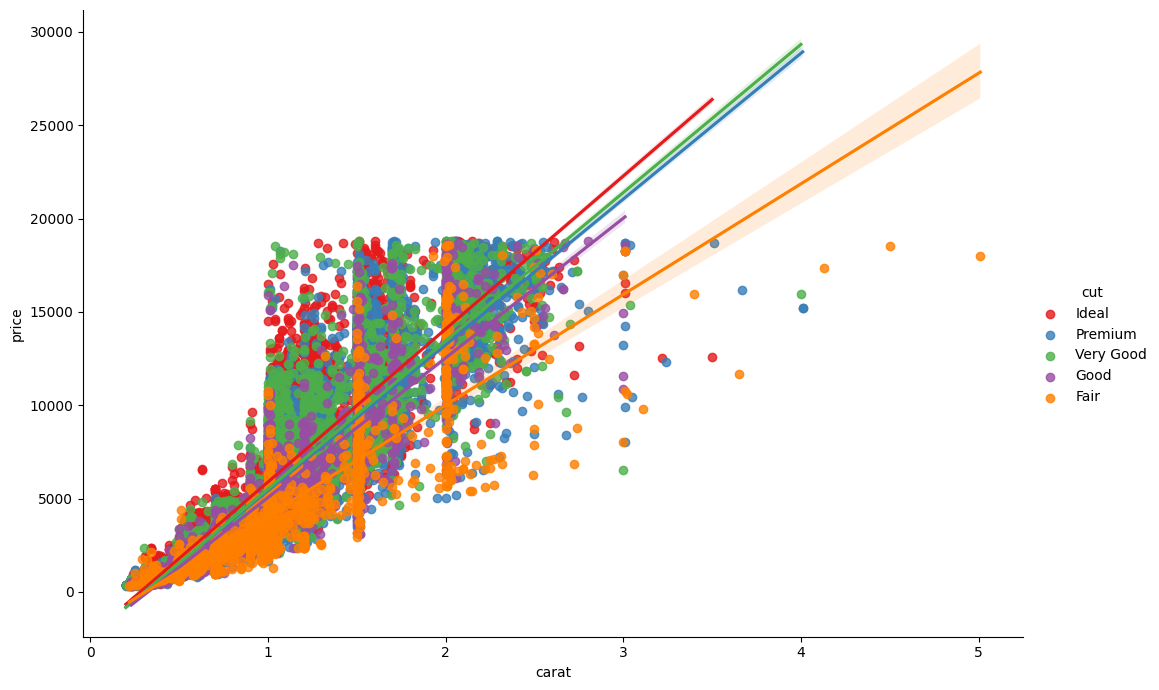

In [25]:


# Gráfico de dispersión con una línea de regresión lineal diferenciada por el tipo de corte
sns.lmplot(x='carat', y='price', data=diamonds, hue='cut', palette="Set1", height=7, aspect=1.5)

# Regresión lineal para el corte "Ideal"
ideal = diamonds[diamonds['cut'] == 'Ideal']
model_ideal = sm.OLS.from_formula('price ~ carat', data=ideal).fit()
print("\nResumen de la regresión lineal para el corte: Ideal")
print(model_ideal.summary())

# Regresión lineal para el corte "Premium"
premium = diamonds[diamonds['cut'] == 'Premium']
model_premium = sm.OLS.from_formula('price ~ carat', data=premium).fit()
print("\nResumen de la regresión lineal para el corte: Premium")
print(model_premium.summary())

# Regresión lineal para el corte "Good"
good = diamonds[diamonds['cut'] == 'Good']
model_good = sm.OLS.from_formula('price ~ carat', data=good).fit()
print("\nResumen de la regresión lineal para el corte: Good")
print(model_good.summary())

# Regresión lineal para el corte "Very Good"
very_good = diamonds[diamonds['cut'] == 'Very Good']
model_very_good = sm.OLS.from_formula('price ~ carat', data=very_good).fit()
print("\nResumen de la regresión lineal para el corte: Very Good")
print(model_very_good.summary())

# Regresión lineal para el corte "Fair"
fair = diamonds[diamonds['cut'] == 'Fair']
model_fair = sm.OLS.from_formula('price ~ carat', data=fair).fit()
print("\nResumen de la regresión lineal para el corte: Fair")
print(model_fair.summary())

# Mostrar la gráfica
plt.show()
